# **Flujo del desarrollo**

1)

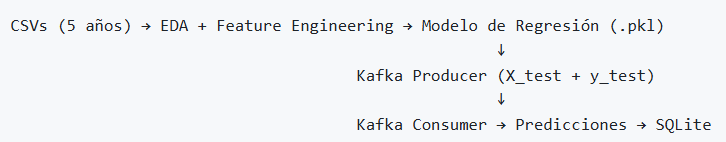

# **FUENTE**

**https://www.kaggle.com/datasets/unsdsn/world-happiness**

# **Configuracion Inicial**

In [37]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
base_path = "/content/drive/Shared drives/ETL_workshop_3/"

# **Extraccion y exploracion de datos**

In [40]:
paths = {
    "2015": base_path + "2015.csv",
    "2016": base_path + "2016.csv",
    "2017": base_path + "2017.csv",
    "2018": base_path + "2018.csv",
    "2019": base_path + "2019.csv",
}

In [41]:
for year, path in paths.items():
    df = pd.read_csv(path)
    print(f"\n{year}: {list(df.columns)}")


2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

2019: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Socia

In [42]:
df_prueba1 = pd.read_csv(base_path + "2019.csv")
df_prueba1["Social support"]

,Social support
0,1.587
1,1.573
2,1.582
3,1.624
4,1.522
...,...
151,0.711
152,0.885
153,0.517
154,0.000


In [43]:
df_prueba2 = pd.read_csv(base_path + "2015.csv")
df_prueba2["Family"]

,Family
0,1.34951
1,1.40223
2,1.36058
3,1.33095
4,1.32261
...,...
153,0.77370
154,0.35386
155,0.47489
156,0.41587


In [44]:
df_prueba2["Trust (Government Corruption)"]

,Trust (Government Corruption)
0,0.41978
1,0.14145
2,0.48357
3,0.36503
4,0.32957
...,...
153,0.55191
154,0.08010
155,0.18906
156,0.10062


In [45]:
df_prueba1["Perceptions of corruption"]

,Perceptions of corruption
0,0.393
1,0.410
2,0.341
3,0.118
4,0.298
...,...
151,0.411
152,0.147
153,0.025
154,0.035


In [46]:
(df_prueba2["Country"] == "Dystopia").sum()

np.int64(0)

-**Mapeo**

In [47]:
#Solo mapeamos caracteristicas que nos puedan servir para el modelo de regresion
mapeo = {
    "2015": {
        "Country":                       "country",
        "Happiness Score":               "happiness_score",
        "Economy (GDP per Capita)":      "gdp_per_capita",
        "Family":                        "social_support",
        "Health (Life Expectancy)":      "life_expectancy",
        "Freedom":                       "freedom",
        "Trust (Government Corruption)": "trust_gov",
        "Generosity":                    "generosity",
    },
    "2016": {
        "Country":                       "country",
        "Happiness Score":               "happiness_score",
        "Economy (GDP per Capita)":      "gdp_per_capita",
        "Family":                        "social_support",
        "Health (Life Expectancy)":      "life_expectancy",
        "Freedom":                       "freedom",
        "Trust (Government Corruption)": "trust_gov",
        "Generosity":                    "generosity",
    },
    "2017": {
        "Country":                       "country",
        "Happiness.Score":               "happiness_score",
        "Economy..GDP.per.Capita.":      "gdp_per_capita",
        "Family":                        "social_support",
        "Health..Life.Expectancy.":      "life_expectancy",
        "Freedom":                       "freedom",
        "Trust..Government.Corruption.": "trust_gov",
        "Generosity":                    "generosity",
    },
    "2018": {
        "Country or region":             "country",
        "Score":                         "happiness_score",
        "GDP per capita":                "gdp_per_capita",
        "Social support":                "social_support",
        "Healthy life expectancy":       "life_expectancy",
        "Freedom to make life choices":  "freedom",
        "Perceptions of corruption":     "trust_gov",
        "Generosity":                    "generosity",
    },
    "2019": {
        "Country or region":             "country",
        "Score":                         "happiness_score",
        "GDP per capita":                "gdp_per_capita",
        "Social support":                "social_support",
        "Healthy life expectancy":       "life_expectancy",
        "Freedom to make life choices":  "freedom",
        "Perceptions of corruption":     "trust_gov",
        "Generosity":                    "generosity",
    },
}

**Seleccion de caracteristica**


In [48]:
#seleccion de caracteristicas a usar
features = [
    "gdp_per_capita",
    "social_support",
    "life_expectancy",
    "freedom",
    "trust_gov",
    "generosity",
]
#seleccion de la variable a predecir (objetivo)
target = "happiness_score"

**Carga y concatenacion de los df**

In [49]:
def load_year(path: str, year: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    mapping = mapeo[year] #acceder a los valores asociados a esa clave
    df = df[[col for col in mapping if col in df.columns]]
    df = df.rename(columns=mapping)  #las renombra con el mapeo para tenerlas igual
    df["year"] = int(year)  #añade la columna año
    return df

frames = []
for year, path in paths.items():  #.items() devuelve clave -> year --- valor ->path
    df = load_year(path, year)  #aplica la funcion definida previamente
    frames.append(df) #guarda el df
    print(f"  {paths[year]}, -> {len(df):3d} filas | columnas: {list(df.columns)}")

df_raw = pd.concat(frames, ignore_index=True) #concatena todos los df
print(f"\nTotal combinado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
df_raw.head()

  /content/drive/Shared drives/ETL_workshop_3/2015.csv, -> 158 filas | columnas: ['country', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'trust_gov', 'generosity', 'year']
  /content/drive/Shared drives/ETL_workshop_3/2016.csv, -> 157 filas | columnas: ['country', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'trust_gov', 'generosity', 'year']
  /content/drive/Shared drives/ETL_workshop_3/2017.csv, -> 155 filas | columnas: ['country', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'trust_gov', 'generosity', 'year']
  /content/drive/Shared drives/ETL_workshop_3/2018.csv, -> 156 filas | columnas: ['country', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'trust_gov', 'generosity', 'year']
  /content/drive/Shared drives/ETL_workshop_3/2019.csv, -> 156 filas | columnas: ['country', 'happiness_score', 'gdp_per_capita', 'social_support', 

,country,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,trust_gov,generosity,year
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


**Limpieza**

In [50]:
#limpieza
cols = features + [target]  #une las 2 listas para tener las columnas

#convertir a numerico (todas las columnas que seleccionamos tienen numeros asi que nos aseguramos que se guarden como tal y no como string por ejemplo)
for col in cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

#eliminar filas sin target
len_antes = len(df_raw)
df_clean = df_raw.dropna(subset=[target]).copy()
print(f"Filas eliminadas por target nulo: {len_antes - len(df_clean)}")

########33
#print(df_clean.head(10))

# Imputar features faltantes

#for col in features:
 ##  if conteo_nulos:
        #df_clean[col] = df_clean.groupby("year")[col].transform(lambda s: s.fillna(s.median()))
        #print(f"  Imputados {null_count} valores en '{col}'")
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_clean[features] = imputer.fit_transform(df_clean[features])
nulos_restantes = df_clean[features].isna().sum().sum()
print(f"Nulos restantes tras imputación KNN: {nulos_restantes}")

Filas eliminadas por target nulo: 0
Nulos restantes tras imputación KNN: 0


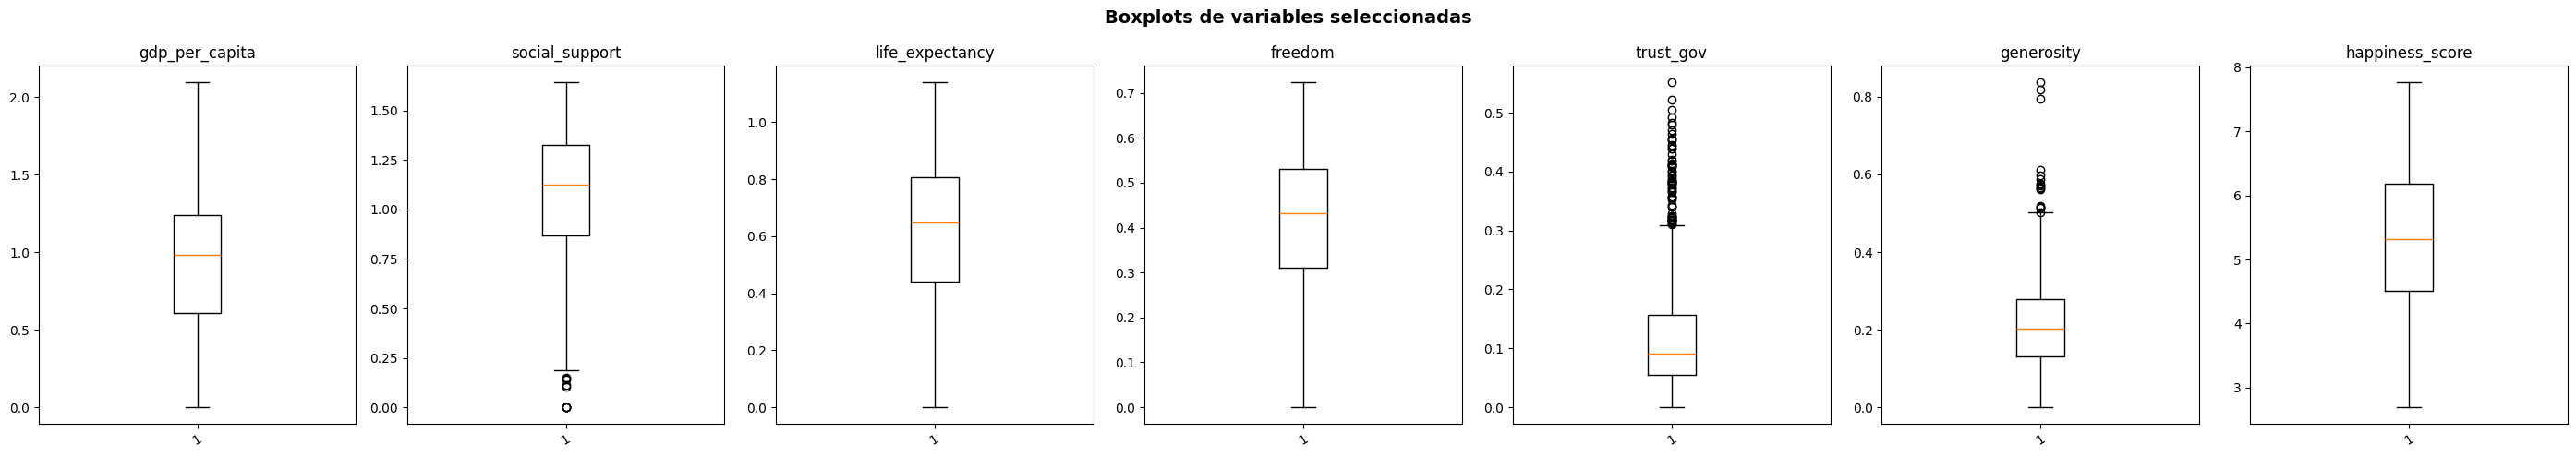

In [51]:
n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 5))  # una fila, n columnas

for i, col in enumerate(cols):
    axes[i].boxplot(df_clean[col].dropna())  # dropna para evitar problemas
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Boxplots de variables seleccionadas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
print("Columna               Valor minimo         Valor maximo")
for col in cols:
  print(f"{col:18s} |  {df[col].min()}                  {df[col].max()}")

Columna               Valor minimo         Valor maximo
gdp_per_capita     |  0.0                  1.684
social_support     |  0.0                  1.624
life_expectancy    |  0.0                  1.141
freedom            |  0.0                  0.631
trust_gov          |  0.0                  0.453
generosity         |  0.0                  0.566
happiness_score    |  2.853                  7.769


- trust_gov Y generosity tienen outliers pero no son outliers imposibles asi que decido no quitarlos. Los aoutliers de las demas columnas son insignificantes

In [53]:
# Eliminar outliers extremos (IQR × 3) (no 1.5 como se hace normalmente)
#for col in cols:
 #   Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
  ###if mask.sum():
     #   print(f"  Outliers eliminados en '{col}': {mask.sum()}")
      #  df_clean = df_clean[~mask] #filta el df usando la negacion de la mascara (cambia true por false y viceversa)

#df_clean = df_clean.reset_index(drop=True)
#print(f"\nDataset limpio: {df_clean.shape[0]} filas")
#df_clean.head()

In [54]:
#seleccion de caracteristicas (features)
X = df_clean[features].copy()
y = df_clean[target].copy()

corr = df_clean[features + [target]].corr()
print("Matriz de correlación:\n")
print(corr.to_string())

print("\n"*2, "Correlación de features con happiness_score:")
corr = df_clean[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print(corr.to_string())

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nEstadísticas de X:")
display(X.describe().round(4))

Matriz de correlación:

                 gdp_per_capita  social_support  life_expectancy   freedom  trust_gov  generosity  happiness_score
gdp_per_capita         1.000000        0.585966         0.784338  0.340511   0.312407   -0.014560         0.789284
social_support         0.585966        1.000000         0.572650  0.420361   0.123062   -0.037262         0.648799
life_expectancy        0.784338        0.572650         1.000000  0.340745   0.250296    0.010638         0.742456
freedom                0.340511        0.420361         0.340745  1.000000   0.455163    0.290706         0.551258
trust_gov              0.312407        0.123062         0.250296  0.455163   1.000000    0.316922         0.400357
generosity            -0.014560       -0.037262         0.010638  0.290706   0.316922    1.000000         0.137578
happiness_score        0.789284        0.648799         0.742456  0.551258   0.400357    0.137578         1.000000


 Correlación de features con happiness_score:
gdp_per_

,gdp_per_capita,social_support,life_expectancy,freedom,trust_gov,generosity
count,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000
mean,0.9160,1.0784,0.6124,0.4111,0.1258,0.2186
std,0.4073,0.3295,0.2483,0.1529,0.1061,0.1223
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.6065,0.8694,0.4402,0.3098,0.0542,0.1300
50%,0.9822,1.1247,0.6473,0.4310,0.0910,0.2020
75%,1.2362,1.3272,0.8080,0.5310,0.1562,0.2788
max,2.0960,1.6440,1.1410,0.7240,0.5519,0.8381


In [55]:
#guardar data luego del procesamiento
output_path = base_path + "df_clean.csv"
df_clean[["country", "year"] + features + [target]].to_csv(output_path, index=False)
print(f"\nDataset limpio guardado → {output_path}")


Dataset limpio guardado → /content/drive/Shared drives/ETL_workshop_3/df_clean.csv


-Se piensa en incluir el año como variable predictora pero no hay cambios visibles entre el score de felicidad y los años por lo que no se incluye.

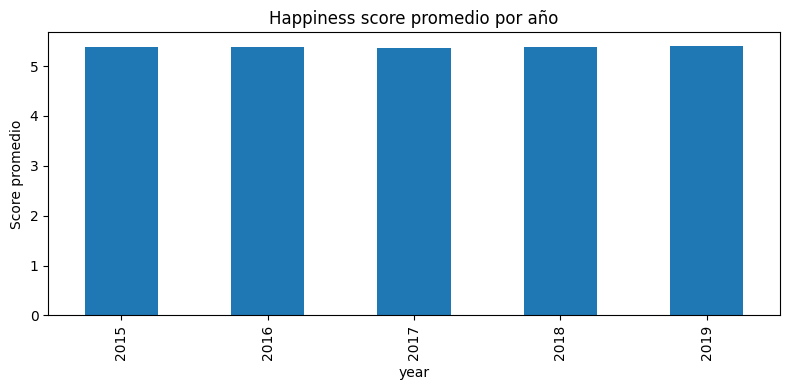

In [56]:
import matplotlib.pyplot as plt

df_clean.groupby("year")["happiness_score"].mean().plot(
    kind="bar", figsize=(8, 4), title="Happiness score promedio por año")

plt.ylabel("Score promedio")
plt.tight_layout()
plt.show()

# **-Modelo**

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [58]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2:", r2)

R^2: 0.7330111838089348


In [60]:
print("Coeficientes:", reg.coef_)

Coeficientes: [1.14030153 0.64419324 1.00873704 1.4783645  0.86346955 0.59167307]


In [61]:
print("Intercepto:", reg.intercept_)

Intercepto: 2.1763305868324507


**-Guardar modelo**

In [62]:
import joblib

joblib.dump(reg, base_path + "model.pkl")
print("Modelo guardado")


# Cargar en el consumer
#model = joblib.load(base_path + "model.pkl")

Modelo guardado


**Guardar X_test y y_test**

In [63]:
X_test.to_csv(base_path + "X_test.csv", index=False)
y_test.to_csv(base_path + "y_test.csv", index=False)

# **----------------------------------------------------------------------------**

# **Kafka**

# **----------------------------------------------------------------------------**

# **Kafka Producer**

**Instalar Kafka**

In [64]:
# Descargar Kafka desde el archivo oficial de Apache
!wget -q https://archive.apache.org/dist/kafka/3.7.0/kafka_2.13-3.7.0.tgz
!tar -xzf kafka_2.13-3.7.0.tgz

# Configurar el almacenamiento usando KRaft (sin Zookeeper)
!uuid=$(./kafka_2.13-3.7.0/bin/kafka-storage.sh random-uuid) && ./kafka_2.13-3.7.0/bin/kafka-storage.sh format -t $uuid -c ./kafka_2.13-3.7.0/config/kraft/server.properties

# Iniciar el servidor de Kafka en modo "daemon" (segundo plano)
!./kafka_2.13-3.7.0/bin/kafka-server-start.sh -daemon ./kafka_2.13-3.7.0/config/kraft/server.properties

# Instalar la librería oficial de Confluent para Python
!pip install -q confluent-kafka

# Damos unos segundos para asegurar que el broker esté arriba y escuchando
import time
print("Iniciando Broker de Kafka local...")
time.sleep(10)
print("¡Entorno listo!")

^C

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
Error: Could not find or load main class kafka.tools.StorageTool
Caused by: java.lang.ClassNotFoundException: kafka.tools.StorageTool
Iniciando Broker de Kafka local...
¡Entorno listo!


In [65]:
def kafka_producer():
    import json
    import time
    import pandas as pd
    from confluent_kafka import Producer

    conf = {"bootstrap.servers": "localhost:9092"}
    producer = Producer(conf)

    def reporte_entrega(err, msg):
        if err is not None:
            print(f"Error al entregar mensaje: {err}", flush=True)
        else:
            print(f"Mensaje entregado a {msg.topic()} [Partición {msg.partition()}]", flush=True)

    topico = "happiness-features"

    dfX = pd.read_csv("/content/drive/Shared drives/ETL_workshop_3/X_test.csv")
    dfy = pd.read_csv("/content/drive/Shared drives/ETL_workshop_3/y_test.csv")
    cols1 = list(dfX.columns)
    rows1 = dfX.values.tolist()
    cols2 = list(dfy.columns)
    rows2 = dfy.values.tolist()

    for i in range(1, 3):
      if i == 1:
        rows = rows1
        cols = cols1
        nombre = "X_test"
      else:
        rows = rows2
        cols = cols2
        nombre = "y_test"

      print(f"Publicando {nombre} con {len(rows)} registros en el topic '{topico}'...", flush=True)
      print(f"Columnas: {cols}", flush=True)
      print("-" * 50)

      for i, row in enumerate(rows):
          mensaje = dict(zip(cols, row))
          producer.produce(
              topico,
              value=json.dumps(mensaje).encode("utf-8"),
              callback=reporte_entrega,)
          producer.poll(0)
          print(f"  [{i+1}/{len(rows)}] Enviado: {mensaje}", flush=True)
          time.sleep(0.1)

      producer.flush()
      print("-" * 50)
      print("Todos los registros enviados.", flush=True)

#kafka_producer()

# **Kafka consumer**

In [66]:
def kafka_consumer():

    import json
    import sqlite3
    import pandas as pd
    import joblib
    from confluent_kafka import Consumer, KafkaError

    base_path = "/content/drive/Shared drives/ETL_workshop_3/"

    conf = {
        "bootstrap.servers": "localhost:9092",
        "group.id":          "happiness-group",
        "auto.offset.reset": "earliest",
    }
    consumer = Consumer(conf)
    consumer.subscribe(["happiness-features"])

    model = joblib.load(base_path + "model.pkl")

    buffer_x = []
    buffer_y = []

    print("Escuchando mensajes en happiness-features...", flush=True)
    print("-" * 50, flush=True)

    try:
        while True:
            msg = consumer.poll(timeout=5.0)

            if msg is None:
                # Sin mensajes nuevos en 5 segundos asumimos que terminó el stream
                if buffer_x and buffer_y:
                    break
                continue

            if msg.error():
                if msg.error().code() == KafkaError._PARTITION_EOF:
                    continue
                print(f"Error: {msg.error()}", flush=True)
                break

            datos = json.loads(msg.value().decode("utf-8"))

            # detectar tipo de mensaje por las claves que trae
            if "happiness_score" in datos:
                buffer_y.append(datos["happiness_score"])
                print(f"  [y_test] score real recibido: {datos['happiness_score']:.4f}", flush=True)
            else:
                buffer_x.append(datos)
                print(f"  [X_test] features recibidas: {datos}", flush=True)

    finally:
        consumer.close()

    #Predecir y guardar
    print("-" * 50)
    print(f"Registros X recibidos: {len(buffer_x)}", flush=True)
    print(f"Registros y recibidos: {len(buffer_y)}", flush=True)

    df_x = pd.DataFrame(buffer_x)
    y_pred = model.predict(df_x)

    #tabla de resultados
    df_result = df_x.copy()
    df_result["y_real"]      = buffer_y
    df_result["y_prediccion"] = y_pred

    print("\nMuestra de predicciones:", flush=True)
    print(df_result[["y_real", "y_prediccion"]].head())

    # guardar en SQLite
    db_path = base_path + "happiness_predictions.db"
    conn = sqlite3.connect(db_path)

    df_result.to_sql("predicciones", conn, if_exists="replace", index=False)

    conn.close()
    print(f"\nPredicciones guardadas en {db_path} → tabla 'predicciones'", flush=True)

#kafka_consumer()

**En paralelo**

In [67]:
import threading

consumer_thread = threading.Thread(target = kafka_consumer)
producer_thread = threading.Thread(target = kafka_producer)
consumer_thread.start()
producer_thread.start()
consumer_thread.join()
producer_thread.join()

**Metricas**

In [69]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE (%): ", (mean_absolute_percentage_error(y_test, y_pred)*100))

Escuchando mensajes en happiness-features...RMSE: 0.5773650167413632

MAE:--------------------------------------------------
 0.44467030800111146
MAPE (%):  9.037135396963656


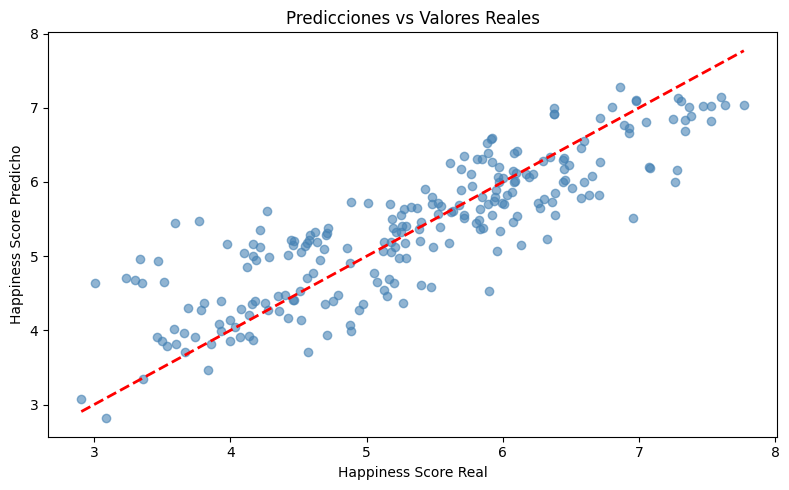

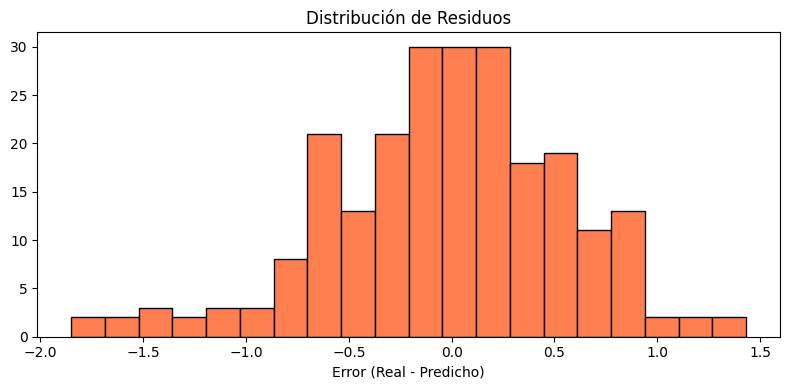

In [70]:
#Predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Happiness Score Real")
plt.ylabel("Happiness Score Predicho")
plt.title("Predicciones vs Valores Reales")
plt.tight_layout()
plt.show()

#Distribución del error
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=20, color='coral', edgecolor='black')
plt.xlabel("Error (Real - Predicho)")
plt.title("Distribución de Residuos")
plt.tight_layout()
plt.show()

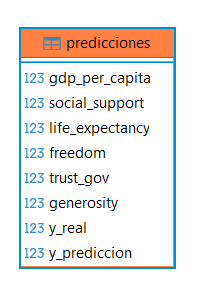

In [71]:
len(X_test) #len de X_test = len de y_test

235

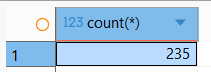

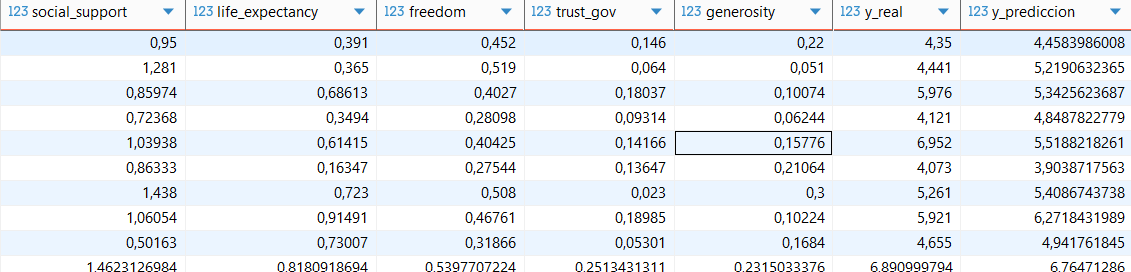